##### Instructions

Complete every code location marked **`TODO`**. Run the notebook from top to bottom after completing each section.

By the end of this exercise, you should be able to:

1. implement centroid initialization, assignment, and update steps in K-means;
2. calculate distortion and the silhouette score;
3. compare a from-scratch implementation with scikit-learn;
4. implement the E-step and M-step of a Gaussian Mixture Model (GMM);
5. monitor log-likelihood and use it as a convergence criterion.

**Rules:** Do not call `sklearn.cluster.KMeans` inside the from-scratch K-means class, and do not call `sklearn.mixture.GaussianMixture` inside the from-scratch GMM class. Small numerical constants such as `1e-9` may be added when needed for stability.

## a) Clustering using K-means

### Program 1 - Implementing K-means Clustering from scratch and using scikit learn

#### AIM

To implement K-means clustering from scratch, evaluate the resulting clusters, and compare the implementation with scikit-learn.

#### K-means algorithm

1. Select $k$ observations as the initial centroids.
2. Assign every observation to its nearest centroid.
3. Replace each centroid by the mean of the observations assigned to it.
4. Repeat steps 2–3 until the centroids stop changing (or a maximum number of iterations is reached).

#### Distortion

In this exercise, distortion is the mean Euclidean distance between every observation and its assigned centroid:

$$D = \frac{1}{N}\sum_{i=1}^{N}\lVert\mathbf{x}_i-\boldsymbol{\mu}_{z_i}\rVert_2.$$

#### Silhouette score

For observation $i$, let $a(i)$ be its mean distance to the other points in its own cluster and let $b(i)$ be the smallest mean distance from it to any other cluster. Then

$$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}, \qquad S=\frac{1}{N}\sum_i s(i).$$

A score near $1$ indicates well-separated clusters, while a score near $-1$ indicates that many observations may be assigned to the wrong cluster.

#### Part 1 - Defining class for KMeans

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.set_printoptions(precision=4, suppress=True)

In [2]:
class KMeans:
    def __init__(self, n_clusters, max_iter=300, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, train_x, random_state=0):
        m = train_x.shape[0]
        rng = np.random.default_rng(random_state)

        # TODO 1: Select `n_clusters` distinct observations as initial centroids.
        # Hint: rng.choice(..., replace=False)
        idx = rng.choice(m, size=self.n_clusters, replace=False)
        self.centroids = train_x[idx].copy()

        for it in range(self.max_iter):
            prev = self.centroids.copy()

            # TODO 2: Assign each training observation to its nearest centroid.
            d = cdist(train_x, self.centroids)
            self.labels = np.argmin(d, axis=1)

            # TODO 3: Update each centroid using the mean of its assigned points.
            # Keep the old centroid if a cluster receives no observations.
            for c in range(self.n_clusters):
                pts = train_x[self.labels == c]
                if len(pts) > 0:
                    self.centroids[c] = pts.mean(axis=0)

            # TODO 4: Stop when the centroid displacement is at most `self.tol`.
            # Hint: np.linalg.norm(self.centroids - old_centroids)
            if np.linalg.norm(self.centroids - prev) <= self.tol:
                break

        self.n_iter_ = it + 1
        return self

    def predict(self, points):
        # TODO 5: Calculate point-to-centroid distances and return the index
        # of the nearest centroid for every point.
        d = cdist(points, self.centroids)
        return np.argmin(d, axis=1)

#### Part 2 — Defining evaluation metrics

Complete both functions without calling their scikit-learn equivalents. Test the edge cases: a single cluster, a singleton cluster, and more than two clusters.

In [3]:
def distortion(X, labels, centroids):
    # TODO 6: Select the assigned centroid for every observation and return
    # the mean Euclidean distance to that centroid.
    c = centroids[labels]
    return np.linalg.norm(X - c, axis=1).mean()


def silhouette_score(X, labels):
    # TODO 7: Implement the mean silhouette score from its definition.
    # Suggested steps:
    #   a. Build the pairwise distance matrix with cdist(X, X).
    #   b. For each point, calculate a(i) from its own cluster.
    #   c. Calculate the mean distance to every other cluster and take b(i).
    #   d. Calculate s(i), treating a singleton cluster's score as 0.
    d = cdist(X, X)
    uq = np.unique(labels)
    s = np.zeros(len(X))

    for c in uq:
        ic = labels == c
        n = ic.sum()

        for i in np.where(ic)[0]:
            if n <= 1:
                s[i] = 0.0
                continue

            sm = ic.copy()
            sm[i] = False
            a = d[i, sm].mean()

            b = np.inf
            for o in uq:
                if o == c:
                    continue
                om = labels == o
                b = min(b, d[i, om].mean())

            s[i] = (b - a) / max(a, b)

    return s.mean()

#### Part 3 — Loading the Iris dataset

We use the copy bundled with scikit-learn so that this notebook does not depend on a separate CSV file. The species column is retained only for the later visual comparison; it is not supplied to either clustering algorithm.

In [4]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris_df = iris.frame.rename(columns={
    "sepal length (cm)": "s_len",
    "sepal width (cm)": "s_wid",
    "petal length (cm)": "p_len",
    "petal width (cm)": "p_wid",
    "target": "species_code",
})
iris_df["species"] = iris_df["species_code"].map(dict(enumerate(iris.target_names)))
iris_df = iris_df.drop(columns="species_code")
names = ["s_len", "s_wid", "p_len", "p_wid", "species"]

display(iris_df.head())
print(
    f"The dataset contains {iris_df.shape[0]} records and "
    f"{iris_df.shape[1] - 1} numerical features.",
    iris_df["species"].value_counts(),
    sep="\n",
)

,s_len,s_wid,p_len,p_wid,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


The dataset contains 150 records and 4 numerical features.
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


#### Part 4 - Implementing K-means Clustering

In [5]:
train_x = iris_df.drop(columns="species").to_numpy()

# TODO 8: Set k to the number of known Iris species, fit your KMeans model,
# and construct `all_df` for the plotting cell below.
k = 3
kmeans = KMeans(n_clusters=k).fit(train_x)

# The completed objects should satisfy the following checks.
assert kmeans is not None, "TODO 8: create and fit the KMeans model"
assert kmeans.centroids.shape == (k, train_x.shape[1])
assert kmeans.labels.shape == (train_x.shape[0],)

all_df = iris_df.copy(deep=True)
centroids = pd.DataFrame(kmeans.centroids, columns=names[:-1])
centroids["cluster"] = "centroid"
all_df["cluster"] = kmeans.labels.astype(str)
all_df = pd.concat([all_df, centroids], ignore_index=True)

#### Part 5 - Comparing the Clustering results with original classes

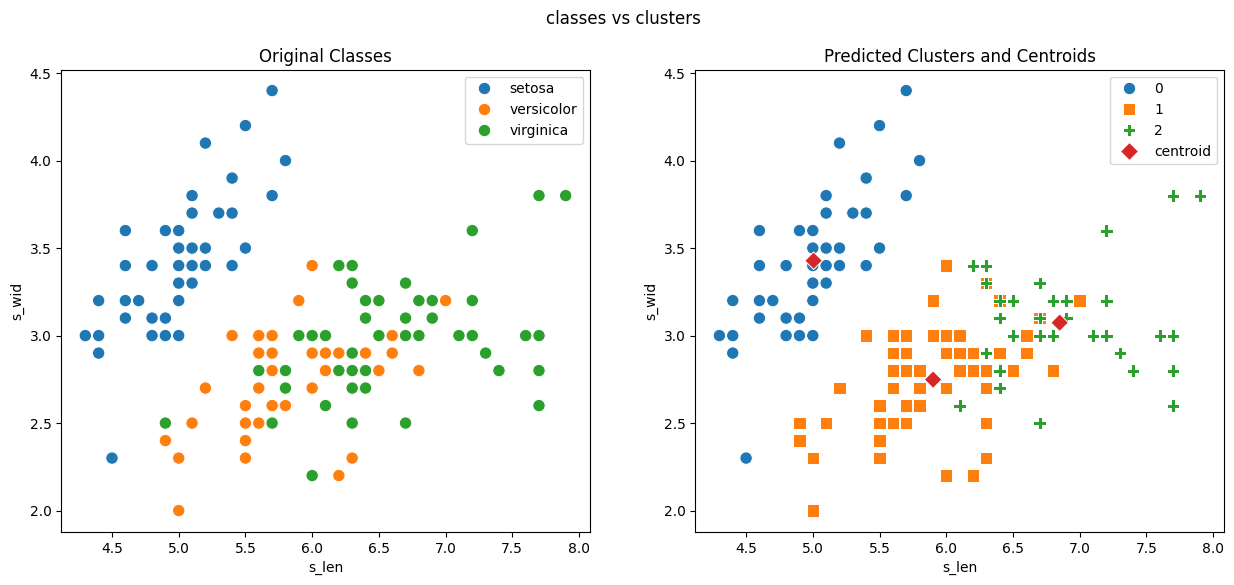

In [6]:
plt.figure(figsize=(15,6))
plt.suptitle("classes vs clusters")
plt.subplot(121)
plt.title("Original Classes")
sns.scatterplot(data=all_df,x="s_len",y="s_wid",hue="species",s=80)
plt.legend(loc="upper right")

plt.subplot(122)
plt.title("Predicted Clusters and Centroids")
sns.scatterplot(
    data=all_df,x="s_len",y="s_wid",
    hue="cluster",style = "cluster",
    markers="osPD",s=80
)
plt.legend(loc="upper right")

plt.show()

#### Part 6 — Hyperparameter tuning with multiple values of $k$

Fit the model for $k=2,3,4,5$. Record both metrics and determine whether they favour the same value of $k$.

In [7]:
sil_coefs = []
distortions = []
K = np.arange(2, 6)

# TODO 9: For each k, fit your KMeans class, calculate both metrics,
# print the results, and append them to the lists above.
for k in K:
    km = KMeans(n_clusters=k).fit(train_x)
    s = silhouette_score(train_x, km.labels)
    d = distortion(train_x, km.labels, km.centroids)
    print(f"k={k}: silhouette={s:.5f}, distortion={d:.5f}")
    sil_coefs.append(s)
    distortions.append(d)

assert len(sil_coefs) == len(K) and len(distortions) == len(K), \
    "TODO 9: store one value of each metric for every k"

k=2: silhouette=0.68105, distortion=0.85558
k=3: silhouette=0.55282, distortion=0.64803
k=4: silhouette=0.49403, distortion=0.56312
k=5: silhouette=0.36780, distortion=0.52004


#### Part 7 - Using Elbow method to Find the optimal value of k

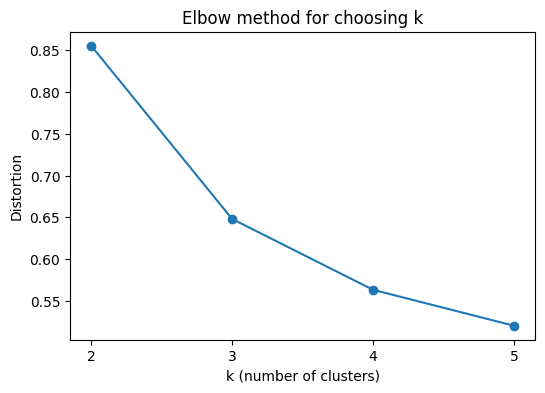

In [8]:
# TODO 10: Plot distortion against k and label both axes.
# Mark each tested value of k on the x-axis.
plt.figure(figsize=(6, 4))
plt.plot(K, distortions, marker="o")
plt.title("Elbow method for choosing k")
plt.xlabel("k (number of clusters)")
plt.ylabel("Distortion")
plt.xticks(K)
plt.show()

#### Part 8 -  Implementing K-means clustering with scikit learn

In [9]:
from sklearn.cluster import KMeans as sklKMeans
from sklearn.metrics import silhouette_score as sk_silhouette_score

In [10]:
# TODO 11: Fit scikit-learn's KMeans for k=3.
# For a reproducible comparison, set init="random", n_init=10, and random_state=0.
# Then calculate its silhouette score and distortion.
k = 3
sk_kmeans = sklKMeans(n_clusters=k, init="random", n_init=10, random_state=0).fit(train_x)
ss = sk_silhouette_score(train_x, sk_kmeans.labels_)
dist = distortion(train_x, sk_kmeans.labels_, sk_kmeans.cluster_centers_)

# TODO 12: Print both metrics to five decimal places and compare them with
# your from-scratch implementation.
print(f"scikit-learn KMeans (k=3): silhouette={ss:.5f}, distortion={dist:.5f}")
print(f"from-scratch KMeans (k=3): silhouette={sil_coefs[1]:.5f}, distortion={distortions[1]:.5f}")

scikit-learn KMeans (k=3): silhouette=0.55282, distortion=0.64803
from-scratch KMeans (k=3): silhouette=0.55282, distortion=0.64803


## b) Clustering using Gaussian Mixture Model(GMM)

### Program 1 — Implementing a GMM from scratch using the Expectation–Maximization algorithm

#### AIM

To implement a Gaussian Mixture Model (GMM) from scratch using the Expectation–Maximization (EM) algorithm and compare two methods for initializing the component means.

#### Formula:

##### Log-likelihood

For $K$ Gaussian components, the observed-data log-likelihood is

$$
\ell(\theta)=\sum_{i=1}^{N}\log\left[\sum_{k=1}^{K}\pi_k\,
\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k)\right].
$$

##### Auxiliary function

$$
Q(\theta,\theta^{(t-1)})=
\sum_i\sum_k r_{ik}\log\pi_k+
\sum_i\sum_k r_{ik}\log p(\mathbf{x}_i\mid\theta_k),
$$

where $r_{ik}=p(z_i=k\mid\mathbf{x}_i,\theta^{(t-1)})$ is the responsibility that component $k$ takes for observation $i$.

##### Responsibility (E-step)

$$
r_{ik}=\frac{\pi_k\,\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k)}
{\sum_{j=1}^{K}\pi_j\,\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_j,\boldsymbol{\Sigma}_j)}.
$$

For every observation $i$, the responsibilities must satisfy $\sum_k r_{ik}=1$.

##### Parameter updates (M-step)

Let $N_k=\sum_i r_{ik}$. Then

$$
\pi_k=\frac{N_k}{N},\qquad
\boldsymbol{\mu}_k=\frac{\sum_i r_{ik}\mathbf{x}_i}{N_k},\qquad
\boldsymbol{\Sigma}_k=
\frac{\sum_i r_{ik}(\mathbf{x}_i-\boldsymbol{\mu}_k)(\mathbf{x}_i-\boldsymbol{\mu}_k)^T}{N_k}.
$$

#### EM algorithm

1. Initialize the component weights, means, and covariance matrices.
2. **E-step:** calculate the posterior responsibility of every component for every observation.
3. **M-step:** update the weights, means, and covariance matrices using those responsibilities.
4. Evaluate the log-likelihood and repeat steps 2–3 until its improvement is no greater than the tolerance.

#### Part 1 - Defining the class for GMM

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans as SklKMeans

In [12]:
class GMM:
    def __init__(
        self, n_components: int, n_iters: int, tol: float,
        random_state: int = 0, init_params: str = "random",
        reg_covar: float = 1e-6,
    ):
        self.n_components = n_components
        self.n_iters = n_iters
        self.tol = tol
        self.init_params = init_params
        self.random_state = random_state
        self.reg_covar = reg_covar

    def fit(self, X, plot=False, plot_params=None):
        if plot_params is None:
            plot_params = {}

        m, n = X.shape
        self.X = X
        k = self.n_components

        self.resp = np.zeros((m, k))
        self.weights = np.full(k, 1 / k)

        rng = np.random.default_rng(self.random_state)

        # TODO 13: Initialize `self.means`.
        # - If init_params == "kmeans", fit SklKMeans and use its centers.
        # - If init_params == "random", select k distinct observations.
        # - Otherwise, raise ValueError for an unsupported method.
        if self.init_params == "kmeans":
            hk = SklKMeans(n_clusters=k, random_state=self.random_state, n_init=10)
            hk.fit(X)
            self.means = hk.cluster_centers_.copy()
        elif self.init_params == "random":
            idx = rng.choice(m, size=k, replace=False)
            self.means = X[idx].copy()
        else:
            raise ValueError(f"Unsupported init_params: {self.init_params!r}")

        # TODO 14: Initialize every covariance matrix using the covariance of X.
        # Add reg_covar * identity for numerical stability.
        bc = np.cov(X, rowvar=False) + self.reg_covar * np.eye(n)
        self.covs = np.array([bc.copy() for _ in range(k)])

        self.converged = False
        self.log_likelihood_trace = []

        if plot:
            fig, ax = plt.subplots(1, 4, figsize=(20, 5))
            fig.suptitle("GMM using Expectation–Maximization")
            self.draw(ax[0], "Initial components", **plot_params)

        for it in range(self.n_iters):
            # TODO 15: Perform one E-step and one M-step.
            ll = self._do_estep(X)
            self._do_mstep(X)

            # TODO 16: Append the current log-likelihood to its trace.
            self.log_likelihood_trace.append(ll)

            if it == 0 and plot:
                self.draw(ax[1], "Components after 1 iteration", **plot_params)

            if it > 0:
                l0, l1 = self.log_likelihood_trace[-2:]
                # TODO 17: Stop if the non-negative log-likelihood improvement
                # is no greater than `self.tol`.
                if (l1 - l0) <= self.tol:
                    self.converged = True
                    break

        self.n_iter_ = it + 1

        if plot:
            self.draw(ax[2], f"Components after {self.n_iter_} iterations", **plot_params)
            ax[3].plot(self.log_likelihood_trace, "-o")
            ax[3].set_title("Log-likelihood")
            ax[3].set_xlabel("Iteration")
            plt.show()

        return self

    def _do_estep(self, X):
        # TODO 18: Calculate the unnormalized responsibilities
        # weights[k] * N(X | mean[k], cov[k]) for every component.
        k = self.n_components
        u = np.zeros((X.shape[0], k))

        for i in range(k):
            u[:, i] = self.weights[i] * multivariate_normal(
                self.means[i], self.covs[i], allow_singular=True
            ).pdf(X)

        # TODO 19: Normalize each row so that it sums to 1, and calculate
        # the total log-likelihood. Use a small lower bound to avoid log(0).
        rt = u.sum(axis=1, keepdims=True)
        st = np.clip(rt, 1e-300, None)

        self.resp = u / st
        return np.log(st).sum()

    def _do_mstep(self, X):
        n = X.shape[1]

        # TODO 20: Calculate effective component counts N_k and update weights.
        w = self.resp.sum(axis=0)
        self.weights = w / X.shape[0]

        # TODO 21: Update the component means.
        for i in range(self.n_components):
            self.means[i] = (self.resp[:, i, None] * X).sum(axis=0) / w[i]

            # TODO 22: Update every covariance matrix using the weighted outer
            # products. Add reg_covar * identity to each matrix.
            c = X - self.means[i]
            wc = (self.resp[:, i, None, None] * (c[:, :, None] @ c[:, None, :])).sum(axis=0)
            self.covs[i] = wc / w[i] + self.reg_covar * np.eye(n)

    def predict_proba(self, X):
        # TODO 23 (extension): Return responsibilities without changing the
        # fitted parameters or the stored training responsibilities.
        k = self.n_components
        u = np.zeros((X.shape[0], k))
        for i in range(k):
            u[:, i] = self.weights[i] * multivariate_normal(
                self.means[i], self.covs[i], allow_singular=True
            ).pdf(X)
        rt = np.clip(u.sum(axis=1, keepdims=True), 1e-300, None)
        return u / rt

    def predict(self, X):
        # TODO 24 (extension): Return the most probable component for each row.
        return np.argmax(self.predict_proba(X), axis=1)

    def draw(self, ax, title="", **plot_params):
        # Plot two-dimensional data, component means, and density contours.
        ax.set_title(title)
        ax.scatter(self.X[:, 0], self.X[:, 1], **plot_params)

        delta = 0.05
        x = np.arange(*ax.get_xlim(), delta)
        y = np.arange(*ax.get_ylim(), delta)
        x, y = np.meshgrid(x, y)
        colors = [f"C{(i + 1) % 10}" for i in range(self.n_components)]

        for i in range(self.n_components):
            mean, cov = self.means[i], self.covs[i]
            z = multivariate_normal(mean, cov).pdf(np.dstack([x, y]))
            ax.scatter(mean[0], mean[1], color=colors[i], marker="X", s=100)
            ax.contour(x, y, z, levels=[0.01], colors=colors[i])

#### Part 2 — Generating random data from a Gaussian mixture

The data-generation function is supplied. Read it carefully and identify where the means and positive-semidefinite covariance matrices are created.

In [13]:
def gen_data(k=3, dim=2, points_per_cluster=200, lim=(-10, 10), seed=1):
    rng = np.random.default_rng(seed)
    samples = np.empty((k, points_per_cluster, dim))
    means = rng.uniform(lim[0], lim[1], size=(k, dim))

    for i in range(k):
        A = rng.random((dim, dim + 10))
        cov = A @ A.T
        samples[i] = rng.multivariate_normal(means[i], cov, points_per_cluster)

    X = samples.reshape(-1, dim)

    if dim == 2:
        plt.figure(figsize=(6, 5))
        plt.title("Generated Gaussian-mixture data")
        plt.scatter(X[:, 0], X[:, 1], s=3, alpha=0.4)
        plt.show()

    return X

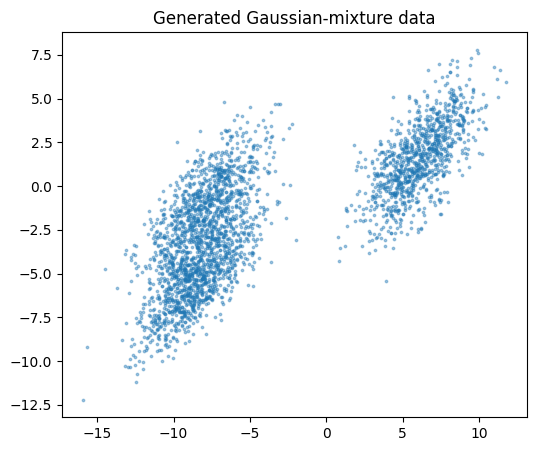

In [14]:
X = gen_data(k=3, dim=2, points_per_cluster=1000, seed=3)

#### Part 3 - Implementing GMM on generated random data

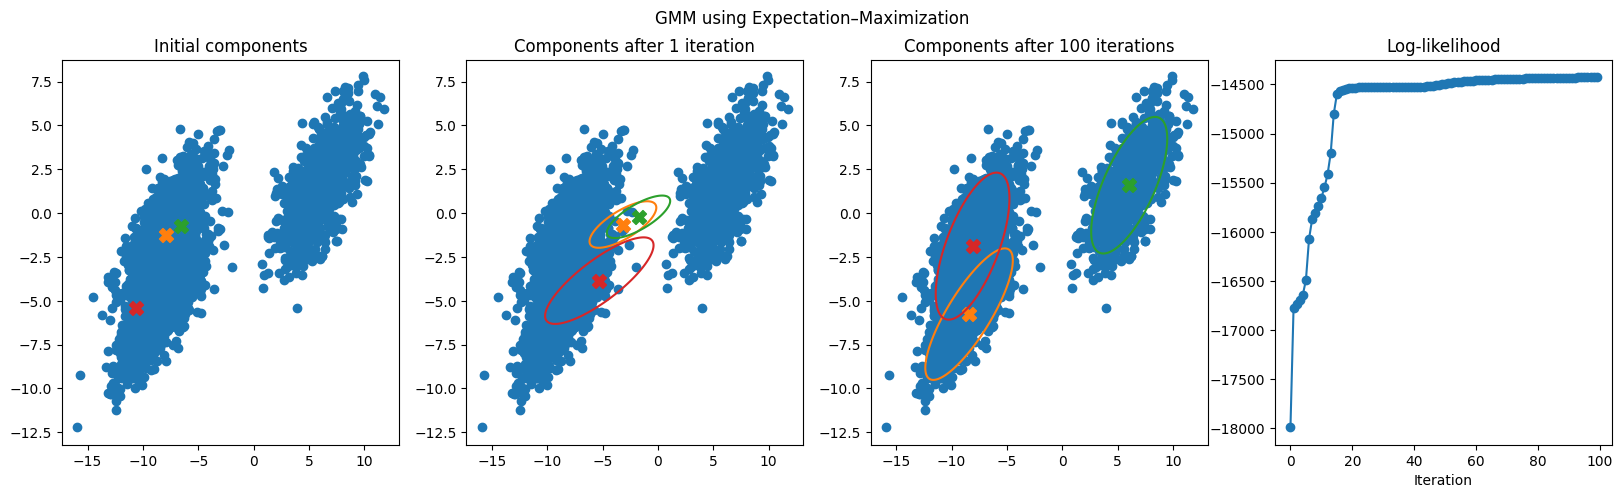

In [15]:
# TODO 25: Create a 3-component GMM with random initialization, fit it to X,
# and display the progress plots. Use n_iters=100, tol=1e-4, random_state=5.
gmm_random = GMM(n_components=3, n_iters=100, tol=1e-4, random_state=5, init_params="random")
gmm_random.fit(X, plot=True)

# After fitting, uncomment these diagnostic checks.
assert np.allclose(gmm_random.weights.sum(), 1.0)
assert np.allclose(gmm_random.resp.sum(axis=1), 1.0)
assert np.all(np.diff(gmm_random.log_likelihood_trace) >= -1e-6)

#### Part 4 - Implementing GMM by using kmeans to initialize means

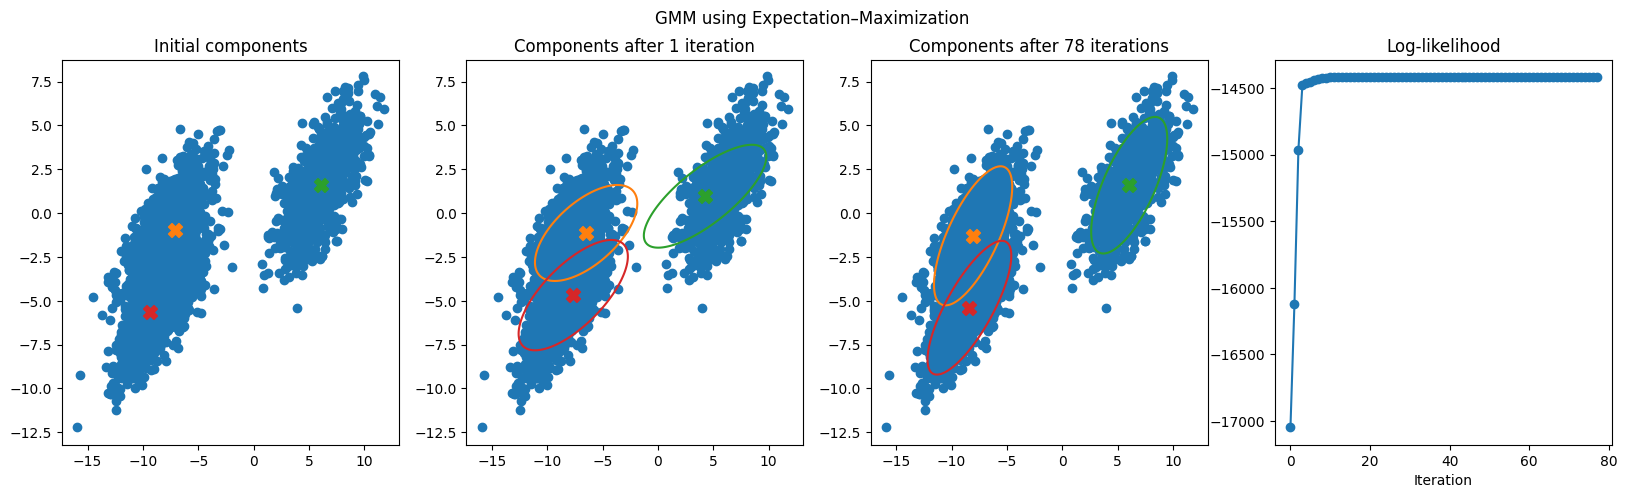

Random init  -> log-likelihood: -14426.1812, iterations: 100
K-means init -> log-likelihood: -14419.1187, iterations: 78


In [16]:
# TODO 26: Repeat the fit with K-means initialization and random_state=1.
gmm_kmeans = GMM(n_components=3, n_iters=100, tol=1e-4, random_state=1, init_params="kmeans")
gmm_kmeans.fit(X, plot=True)

# TODO 27: Compare the two runs using the final log-likelihood and number of
# iterations. Which initialization converged faster? Did both reach the same
# solution? Write your interpretation in the markdown cell below.
print(f"Random init  -> log-likelihood: {gmm_random.log_likelihood_trace[-1]:.4f}, iterations: {gmm_random.n_iter_}")
print(f"K-means init -> log-likelihood: {gmm_kmeans.log_likelihood_trace[-1]:.4f}, iterations: {gmm_kmeans.n_iter_}")

## Results and interpretation
Complete this section after running both algorithms.

1. **Best value of $k$ for Iris:** TODO — report the evidence from the elbow curve and silhouette scores.
2. **From-scratch vs scikit-learn K-means:** TODO — compare the two metric values and comment on initialization.
3. **Random vs K-means initialization for GMM:** TODO — compare convergence speed and final log-likelihood.
4. **K-means vs GMM:** TODO — explain one important difference between hard assignments and probabilistic responsibilities.
5. **Chemistry connection:** TODO — give one chemical dataset for which GMM clustering could be more informative than K-means (for example, overlapping conformer populations or spectra).



**Best value of $k$ for Iris:** The elbow curve continues smoothly from k=2 to k=5 without showing a sudden "elbow," something that is to be expected given that there is some overlap between versicolor and virginica. Although the silhouette score is at its highest when k=2 (0.681) and then decreases noticeably at k=3 (0.553) and even more so at k=4 and k=5, since we know there are three true species k=3 is the biologically appropriate choice; nevertheless, it is geometrically reasonable that the silhouette score favours k=2 because the petal and sepal measurements clearly separate setosa from the other two species, whereas versicolor and virginica overlap so much that they are more cleanly grouped together in k=2 than in k=3. This serves as a good illustration of why an unsupervised metric does not always agree with the known ground truth.

**From-scratch vs scikit-learn K-means:** When k was set to 3, both the from-scratch implementation and scikit-learn's KMeans (using `init="random"`, `n_init=10`, and `random_state=0`) achieved the same values for the metrics: a silhouette score of 0.55282 and a distortion value of 0.64803. It's no surprise that this is the case because K-means has a unique and clearly defined local optimum for data that is well separated like this, and the fact that scikit-learn employs multiple random restarts (`n_init=10`) means that it is very likely to reach the same solution that my version, which only uses one random initialization per fit, converges to. In more complicated or higher-dimensional data, I would expect the two methods to differ at times since my implementation only performs a single random initialization for each fit.

**Random vs K-means initialization for GMM:** The K-means initialization converged more quickly (78 iterations compared to 100, which means the random-init run failed to converge within the allowed number of iterations) and achieved a slightly higher final log-likelihood (-14419.12 as opposed to -14426.18). This is in agreement with the theory since K-means gives the GMM a head start by having its means already close to reasonable cluster centres, so the EM algorithm requires fewer steps to reach a conclusion and is less likely to end up exploring a poor initial configuration.

**K-means vs GMM:** With k-means, there is a definite assignment, each point belongs to only one cluster and there is no concept of confidence. GMM, on the other hand, calculates a responsibility (a probability) for each point with respect to each component, so a point situated near the boundary between two components can be, for example, 60% component A and 40% component B rather than being compelled to go into one cluster. Because of this, GMM is more appropriate for data in which the clusters actually overlap, since it takes account of that ambiguity rather than suppressing it.

**Chemistry connection:** NMR or mass-spectrometry data involving a mixture of overlapping conformers or tautomers of the same molecule provide a good example of this. The spectral peaks that are observed are not clearly separated; instead they result from a continuous distribution of slightly different structural populations which blend into one another. Unlike K-means, which assigns a sample entirely to one conformer, GMMs' probabilistic nature is more appropriate in such a case since they can treat the spectrum sample as a mixture of the underlying populations.